In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

class AZHandwrittenDataset(Dataset):
    def __init__(self, features, labels):
        self.features = torch.tensor(features, dtype=torch.float32) / 255.0
        self.labels = torch.tensor(labels, dtype=torch.long)
        
    def __len__(self):
        return len(self.labels)
        
    def __getitem__(self, idx):
        return self.features[idx], self.labels[idx]

dataset_path = 'A_Z Handwritten Data.csv'

try:
    print("Loading dataset (this might take a minute as the CSV is large)...")
    df = pd.read_csv(dataset_path)
    
    y = df.iloc[:, 0].values
    X = df.iloc[:, 1:].values
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    train_dataset = AZHandwrittenDataset(X_train, y_train)
    test_dataset = AZHandwrittenDataset(X_test, y_test)
    
    train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)
    print(f"Dataset loaded! Train size: {len(train_dataset)}, Test size: {len(test_dataset)}")
except FileNotFoundError:
    print(f"Error: Could not find {dataset_path}. Please download it from Kaggle and place it in this folder.")


Using device: cpu
Loading dataset (this might take a minute as the CSV is large)...
Dataset loaded! Train size: 297960, Test size: 74490


In [2]:
class LinearNN(nn.Module):
    def __init__(self, input_size=784, num_classes=26):
        super(LinearNN, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_size, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )
        
    def forward(self, x):
        return self.model(x)

model = LinearNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
print(model)


LinearNN(
  (model): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=512, out_features=256, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=256, out_features=128, bias=True)
    (7): ReLU()
    (8): Linear(in_features=128, out_features=26, bias=True)
  )
)


In [ ]:
epochs = 10
train_losses, test_losses = [], []
train_accs, test_accs = [], []

print("Starting training...")
for epoch in range(epochs):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * inputs.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        
    train_losses.append(running_loss / total)
    train_accs.append(correct / total)
    
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item() * inputs.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
            
    test_losses.append(running_loss / total)
    test_accs.append(correct / total)
    
    print(f"Epoch [{epoch+1}/{epochs}] | Train Loss: {train_losses[-1]:.4f} Acc: {train_accs[-1]:.4f} | Test Loss: {test_losses[-1]:.4f} Acc: {test_accs[-1]:.4f}")

Starting training...
Epoch [1/10] | Train Loss: 0.3378 Acc: 0.9023 | Test Loss: 0.1143 Acc: 0.9673
Epoch [2/10] | Train Loss: 0.1498 Acc: 0.9559 | Test Loss: 0.0901 Acc: 0.9743
Epoch [3/10] | Train Loss: 0.1222 Acc: 0.9639 | Test Loss: 0.0804 Acc: 0.9770
Epoch [4/10] | Train Loss: 0.1088 Acc: 0.9677 | Test Loss: 0.0758 Acc: 0.9779
Epoch [5/10] | Train Loss: 0.0970 Acc: 0.9711 | Test Loss: 0.0624 Acc: 0.9821
Epoch [6/10] | Train Loss: 0.0902 Acc: 0.9731 | Test Loss: 0.0605 Acc: 0.9825
Epoch [7/10] | Train Loss: 0.0845 Acc: 0.9747 | Test Loss: 0.0536 Acc: 0.9844
Epoch [8/10] | Train Loss: 0.0802 Acc: 0.9757 | Test Loss: 0.0541 Acc: 0.9845
Epoch [9/10] | Train Loss: 0.0760 Acc: 0.9771 | Test Loss: 0.0523 Acc: 0.9853
Epoch [10/10] | Train Loss: 0.0729 Acc: 0.9779 | Test Loss: 0.0505 Acc: 0.9861


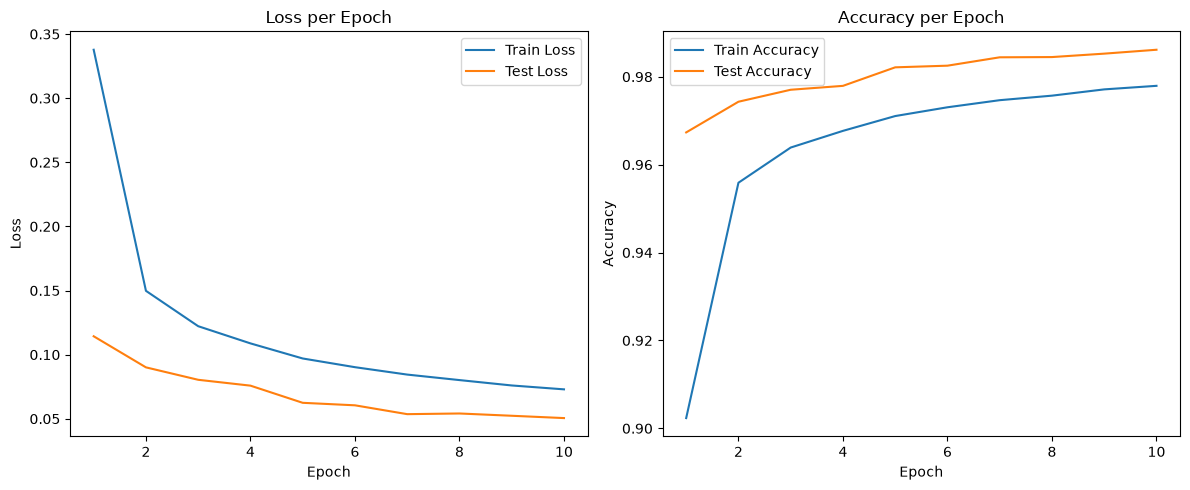

In [ ]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(range(1, epochs+1), train_losses, label='Train Loss')
plt.plot(range(1, epochs+1), test_losses, label='Test Loss')
plt.title('Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(range(1, epochs+1), train_accs, label='Train Accuracy')
plt.plot(range(1, epochs+1), test_accs, label='Test Accuracy')
plt.title('Accuracy per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

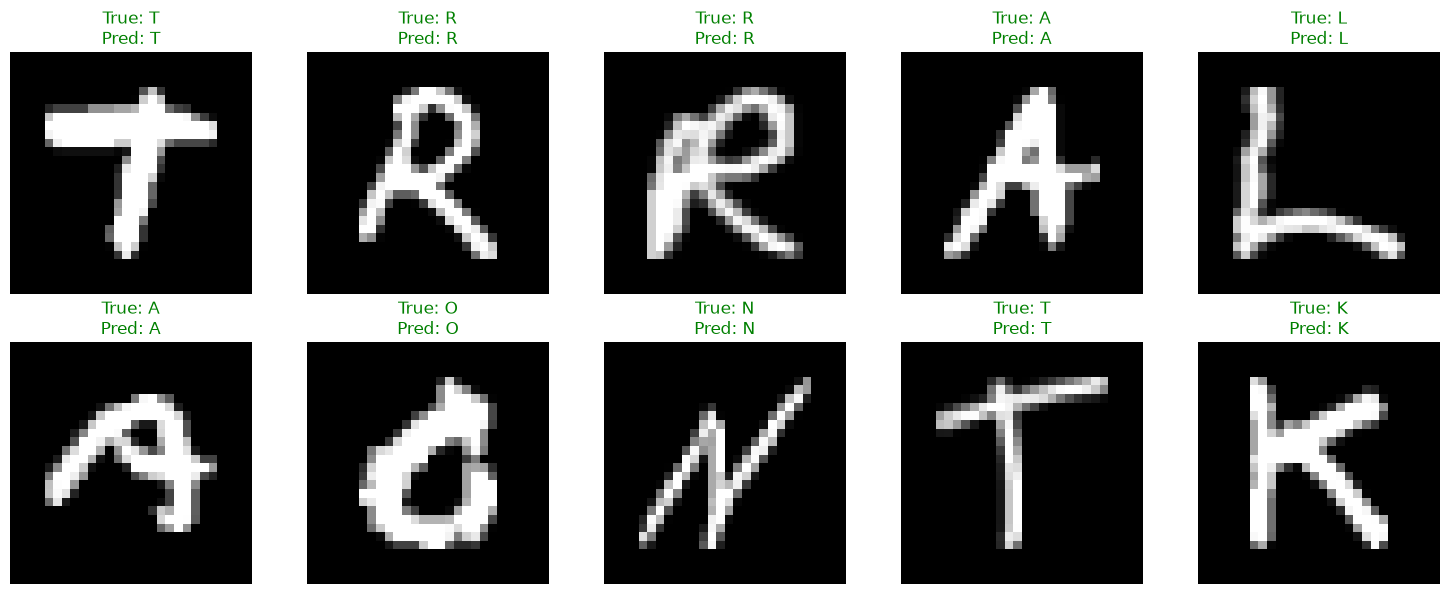

In [ ]:
import string
alphabet = list(string.ascii_uppercase)

model.eval()
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()

dataiter = iter(test_loader)
images, labels = next(dataiter)

indices = np.random.choice(images.size(0), 10, replace=False)

with torch.no_grad():
    for i, idx in enumerate(indices):
        img = images[idx]
        label = labels[idx]
        
        output = model(img.unsqueeze(0).to(device))
        _, predicted = output.max(1)
        
        pred_char = alphabet[predicted.item()]
        true_char = alphabet[label.item()]
        
        img_np = img.view(28, 28).numpy()
        
        axes[i].imshow(img_np, cmap='gray')
        color = 'green' if pred_char == true_char else 'red'
        axes[i].set_title(f"True: {true_char}\nPred: {pred_char}", color=color)
        axes[i].axis('off')

plt.tight_layout()
plt.show()